# Why `solar_leo` and `soil_microbiome` resist every feature

**The question.** Across three separate feature efforts, the same three use cases keep
failing while the same three keep working:

| use case | term overlap | metadata (8 cols) | embedding (OOF) |
|---|---|---|---|
| `cement_binders` | 0.801 | 0.765 | 0.799 |
| `carbon_capture` | 0.709 | 0.593 | 0.775 |
| `ner` | 0.698 | 0.510 | 0.707 |
| `soil_microbiome` | 0.504 | 0.513 | 0.689 |
| `solar_leo` | **0.464** | 0.513 | **0.556** |
| `tech_forecasting` | 0.563 | — | — |

`solar_leo` is the extreme: term overlap is *below* chance and even the sentence embedding
barely clears it. Sources: `terms_overlap.ipynb`, `wf_feature_validation.ipynb`.

**What this notebook finds.** Three things, in order of how much they matter:

1. In both problem corpora the two classes are **interleaved in embedding space** — a
   paper's nearest neighbours carry the *opposite* label more often than chance. Any
   topic-based representation is structurally blind to the axis the analyst used.
2. That axis exists and is recoverable, but it lives in the use case's **`objective`**,
   not in `terms.must_include` — which is why term overlap, which reads only `terms_*`,
   cannot see it. For `soil_microbiome` a two-column hand-built feature reaches **0.727
   out-of-fold, beating the 384-dim embedding**.
3. The reason nobody noticed: **adding a small feature to a raw 384-dim embedding does
   nothing** (+0.001), because the added column is one of 385. Compress the embedding
   first and the same feature is worth **+0.06 to +0.08**. This generalises to all six use
   cases and is the highest-leverage finding here.

**Which critic is speaking.** Single-feature AUCs are full-population reads (no model
fitted). Everything from §4 on is out-of-fold under `StratifiedGroupKFold` grouped by
first author. §6's held-out use case is never trained on. Judgement calls are labelled.

**One honesty caveat, stated up front.** The `soil_microbiome` term lists in §3 were
written *after* reading ~16 labelled titles from that corpus, so their AUC on that same
corpus is optimistically biased. §3 reports a split-half check, but the only unbiased test
is whether the *method* — derive the axis from the use case's `objective` — works on a
corpus nobody has read. That test is not run here.

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, normalize

warnings.filterwarnings("ignore")
DATA_PATH = "../../data/processed/papers_combined.parquet"
HOLDOUT_USE_CASE, N_SPLITS, RANDOM_STATE = "tech_forecasting", 5, 42

ACCENT, WARM, MUTED = "#2a78d6", "#e34948", "#96948c"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})
pd.set_option("display.width", 220)

df = pd.read_parquet(DATA_PATH)
df["text"] = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.lower()
labelled = df[df["triage_label"].isin(["positive", "negative"])].copy()
labelled["y"] = (labelled["triage_label"] == "positive").astype(int)
print(f"{len(labelled)} labelled positive/negative rows across {labelled.use_case_key.nunique()} use cases")


def first_author(s):
    if pd.isna(s) or not s.strip():
        return None
    return re.sub(r"\s+", " ", s.split(",")[0].strip())


def grouped_oof(d, X, clf="lr", n_splits=N_SPLITS):
    "Out-of-fold predictions, folds grouped by first author so no author spans folds."
    d = d.reset_index(drop=True)
    groups = d["authors"].apply(first_author).fillna(d["paper_id"])
    folds = StratifiedGroupKFold(n_splits, shuffle=True, random_state=RANDOM_STATE)
    pred = np.full(len(d), np.nan)
    for tr, te in folds.split(np.arange(len(d)), d["y"], groups):
        m = (Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                       ("c", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
             if clf == "lr" else HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        m.fit(X[tr], d["y"][tr])
        pred[te] = m.predict_proba(X[te])[:, 1]
    return roc_auc_score(d["y"], pred)

1852 labelled positive/negative rows across 6 use cases


## 1. The mechanism — are the classes even separable in embedding space?

Before asking which feature to add, ask whether the representation *can* separate these
labels at all. For each labelled paper, take its 10 nearest neighbours by cosine
similarity **within its own use case** and measure how often they share its label.

The benchmark is the majority-class rate: if 77% of a corpus is positive, then 77%
agreement is what you get by knowing nothing. **Agreement below that means the classes are
interleaved** — topically similar papers systematically disagree on the label.

In [2]:
rows = []
for uc, g in labelled.groupby("use_case_key"):
    E = normalize(np.vstack(g["embedding"].to_numpy()))
    S = E @ E.T
    np.fill_diagonal(S, -9)                      # a paper is not its own neighbour
    nn = np.argsort(-S, axis=1)[:, :10]
    y = g["y"].to_numpy()
    agree = (y[nn] == y[:, None]).mean()
    majority = max(y.mean(), 1 - y.mean())
    rows.append({"use_case": uc, "n": len(g), "knn_agreement": round(agree, 3),
                 "majority_baseline": round(majority, 3), "lift": round(agree - majority, 3)})
knn = pd.DataFrame(rows).sort_values("lift").set_index("use_case")
print(knn.to_string())

                    n  knn_agreement  majority_baseline   lift
use_case                                                      
soil_microbiome   357          0.656              0.737 -0.080
solar_leo         360          0.703              0.767 -0.064
ner               312          0.699              0.715 -0.015
tech_forecasting  264          0.604              0.595  0.009
cement_binders    262          0.760              0.649  0.111
carbon_capture    297          0.636              0.505  0.131


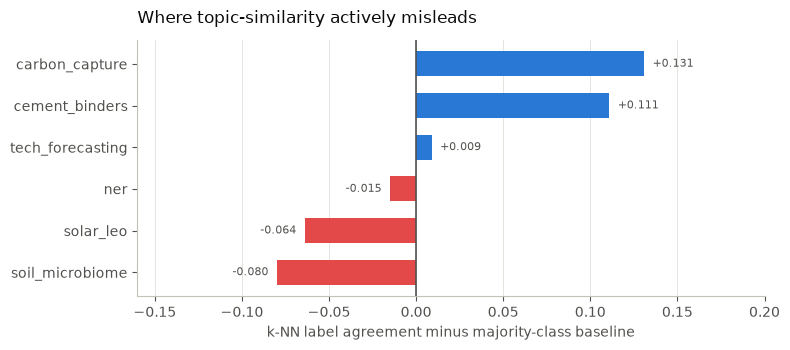

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.6))
k = knn.sort_values("lift")
colors = [WARM if v < 0 else ACCENT for v in k["lift"]]
ax.barh(k.index, k["lift"], color=colors, height=0.6)
ax.axvline(0, color="#52514e", lw=1.2)
ax.set_xlabel("k-NN label agreement minus majority-class baseline")
ax.set_title("Where topic-similarity actively misleads", loc="left", pad=12)
for name, v in k["lift"].items():
    ax.annotate(f"{v:+.3f}", (v, name), textcoords="offset points",
                xytext=(6 if v > 0 else -6, 0), va="center",
                ha="left" if v > 0 else "right", fontsize=8, color="#52514e")
ax.set_xlim(-0.16, 0.20)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Finding (hard numbers).** The ordering matches the ordering of every feature result in
this repo, which is the point:

- `soil_microbiome` **−0.080** and `solar_leo` **−0.064** — a paper's ten nearest
  neighbours predict its label *worse than guessing the majority class*.
- `carbon_capture` **+0.131** and `cement_binders` **+0.111** — the two that work.

This is the mechanism, not a restatement of the problem. In the two hard corpora,
topically adjacent papers carry opposite labels, so a sentence embedding, a TF-IDF vector
and a term-overlap count are all reading a dimension that is orthogonal to the decision.
Adding a better *topical* feature cannot help; the axis has to come from somewhere else.

## 2. `solar_leo` — the label boundary is vintage, and the analyst said so

Read the negatives. They are not off-topic — most are perovskite solar-cell papers, the
same as the positives.

In [4]:
s = labelled[labelled.use_case_key == "solar_leo"].copy()
print(f"solar_leo: {int(s.y.sum())} positive / {int((1 - s.y).sum())} negative "
      f"({s.y.mean():.1%} positive)\n")
print("--- 8 negatives, oldest first ---")
for _, r in s[s.y == 0].nsmallest(8, "year")[["year", "title"]].iterrows():
    print(f"  {int(r.year)}  {r.title[:88]}")
print("\n--- 8 positives, oldest first ---")
for _, r in s[s.y == 1].nsmallest(8, "year")[["year", "title"]].iterrows():
    print(f"  {int(r.year)}  {r.title[:88]}")

solar_leo: 276 positive / 84 negative (76.7% positive)

--- 8 negatives, oldest first ---
  1991  A low-cost, high-efficiency solar cell based on dye-sensitized colloidal TiO2 films
  1997  Optical absorption of ReS2 and ReSe2 single crystals
  2011  Molecular Mechanisms Underlying Cell Death in Spinal Networks in Relation to Locomotor A
  2014  Performance optimization for Perovskite based solar cells
  2014  Semi-transparent perovskite solar cells for tandems with silicon and CIGS
  2015  Recent Advances in Improving the Stability of Perovskite Solar Cells
  2015  ChemInform Abstract: Understanding the Outstanding Power Conversion Efficiency of Perovs
  2015  Perovskite/crystalline silicon tandem solar cells fabricated by non-vacuum-process

--- 8 positives, oldest first ---
  2015  High-efficiency solution-processed perovskite solar cells with millimeter-scale grains
  2015  Insight into Evolution, Processing and Performance of Multi-length-scale Structures in P
  2015  Solvent engi

In [5]:
s["band"] = pd.cut(s["year"], [1970, 2015, 2018, 2020, 2022, 2024, 2027])
print("positive rate by publication-year band:")
print(s.groupby("band", observed=True).agg(n=("y", "size"), positive_rate=("y", "mean")).round(3).to_string())
print()
for c in ["year", "relevance_score"]:
    print(f"  full-population AUC, {c:16s} {roc_auc_score(s.y, s[c].fillna(s[c].median())):.3f}")
print(f"  embedding, out-of-fold                 "
      f"{grouped_oof(s, np.vstack(s.embedding.to_numpy())):.3f}")

positive rate by publication-year band:


                n  positive_rate
band                            
(1970, 2015]   17          0.353
(2015, 2018]   40          0.300
(2018, 2020]   62          0.629
(2020, 2022]   52          0.981
(2022, 2024]   88          0.920
(2024, 2027]  101          0.861

  full-population AUC, year             0.766
  full-population AUC, relevance_score  0.594
  embedding, out-of-fold                 0.648


**Finding (hard numbers).** Positive rate goes 0.33 (pre-2018) → 0.63 (2018–20) → **0.98**
(2020–22) → 0.92 → 0.86. Plain `year` scores **0.766** — better than the embedding's 0.648
out-of-fold and better than `relevance_score`'s 0.594.

And the 2015 papers straddle the boundary while being the same kind of work:

- *negative*, 2015: "Film Morphology Control For High Efficiency Perovskite Solar Cells"
- *positive*, 2016: "Film Grain-Size Related Long-Term Stability of Inverted Perovskite Solar Cells"

**Why, in the analyst's own words.** `solar-cells-for-low-earth-orbit-satellites.usecase.json`
carries this note:

> Seeded from the reference lists of this field's review papers, so the starting pool is
> CANON — well-cited, established work. […] the papers were chosen because reviews already
> cite them.

and the `objective` asks for approaches that improve efficiency and stability **"beyond
what incumbent technologies currently deliver"**.

Put those together: the corpus was seeded with established canon, and the decision rule
rewards work that goes *beyond* the established. Older canonical papers are the incumbent
almost by definition. **The positive/negative boundary encodes novelty-relative-to-2026,
which is a fact about when the paper was published and what the field already knew — not a
property of the title and abstract.**

That is why the embedding cannot find it, and why `author_count` "worked" here (0.696): it
correlates +0.22 with year on this corpus and is a weaker proxy for the same thing.

**Judgement call.** This is a corpus-construction and labelling-design issue, not a missing
feature. A model can score well here by learning "newer ⇒ positive" — §4 shows two columns
reaching 0.805 — but that rule is about this corpus's vintage distribution and should not
be expected to transfer. The corpus also contains outright retrieval noise labelled
negative (a 2011 spinal-cord neuroscience paper, a 1997 crystal-optics paper), which is a
separate, smaller data-quality problem.

## 3. `soil_microbiome` — the axis is in the `objective`, not in the term list

Here the positives and negatives are genuinely hard to tell apart by topic:

- *positive*: "The Role of Arbuscular Mycorrhizal Fungi in Enhancing Crop Resilience and Soil Health: A Review"
- *negative*: "Microbial Products and Their Role in Soil Health and Sustainable Agriculture"

Both are soil-microbiome-and-crops review papers. Now compare the two halves of the use
case brief:

| field | content |
|---|---|
| `terms.must_include` | soil microbial community, soil fungal community, soil health, crop production, heat stress resistance, … |
| `objective` | "Identify research on microbial and fungal community **management strategies** that enhance soil health, crop productivity, and resistance to…" |

**`terms.must_include` is pure topic vocabulary — which every paper in the corpus shares,
because the corpus was retrieved with it.** The discriminating idea, *management
strategies*, appears only in the `objective`. Term overlap reads `terms_*` only, so it is
structurally incapable of seeing the thing that decides the label.

Test: score each paper on applied-intervention vocabulary versus descriptive-ecology
vocabulary, length-normalised so this is not an abstract-length proxy.

In [6]:
INTERVENTION_RE = re.compile(
    r"engineer|inocul|amendment|biofertil|biochar|applicat|management|treatment|strateg"
    r"|improv|enhanc|mitigat|promot|restor|sustainab")
DESCRIPTIVE_RE = re.compile(
    r"mechanism|assembly|diversity|community structure|dynamics|composition|taxonom"
    r"|phylogen|biogeochem|characteri|survey|distribution|drivers of")

# Rate per 1000 characters, not a raw count -- otherwise this is an abstract-length feature.
length = labelled["text"].str.len().clip(lower=200)
labelled["intervention_rate"] = labelled["text"].str.count(INTERVENTION_RE) / length * 1000
labelled["descriptive_rate"] = labelled["text"].str.count(DESCRIPTIVE_RE) / length * 1000
labelled["framing_axis"] = labelled["intervention_rate"] - labelled["descriptive_rate"]

sm = labelled[labelled.use_case_key == "soil_microbiome"]
print("soil_microbiome, full-population AUC:")
for c in ["intervention_rate", "descriptive_rate", "framing_axis"]:
    p = mannwhitneyu(sm.loc[sm.y == 1, c], sm.loc[sm.y == 0, c]).pvalue
    print(f"  {c:20s} AUC={roc_auc_score(sm.y, sm[c]):.3f}   p={p:.2e}")
print(f"\n  for reference: abstract length  AUC="
      f"{roc_auc_score(sm.y, sm.abstract.fillna('').str.len()):.3f}  <- not a length proxy")

rng = np.random.RandomState(0)
idx = rng.permutation(len(sm))
for name, part in [("half A", sm.iloc[idx[:len(sm) // 2]]), ("half B", sm.iloc[idx[len(sm) // 2:]])]:
    print(f"  split-half stability, {name}: AUC={roc_auc_score(part.y, part.framing_axis):.3f} (n={len(part)})")

soil_microbiome, full-population AUC:


  intervention_rate    AUC=0.687   p=7.36e-08


  descriptive_rate     AUC=0.324   p=3.34e-07
  framing_axis         AUC=0.718   p=3.62e-10

  for reference: abstract length  AUC=0.487  <- not a length proxy
  split-half stability, half A: AUC=0.722 (n=178)
  split-half stability, half B: AUC=0.719 (n=179)


**Finding (hard numbers).** `descriptive_rate` scores **0.324** — strongly inverted,
descriptive-ecology language predicts *negative*. The combined axis reaches **0.718**
full-population (p = 3.6e-10), and splits half/half at 0.722 / 0.719, so it is not carried
by a handful of rows. Abstract length alone is 0.487, so this is not a length proxy.

For comparison on this same corpus: term overlap **0.504**, `relevance_score` **0.542**,
embedding **0.689** out-of-fold. **A two-column regex feature beats all three.**

**Judgement call, and the caveat from the header repeated because it matters:** these
regexes were written after reading ~16 labelled titles from this corpus, so 0.718 on this
corpus is optimistic. The transferable claim is not "use these regexes" — it is *`objective`
and `problem_statement` contain the decision axis and are currently unused by every feature
in the repo.*

## 4. Out-of-fold: does either diagnosis convert into a working feature?

Full-population AUC is a measurement, not a model result. Same features, out-of-fold,
grouped by first author.

In [7]:
results = []
for uc, cols in [("soil_microbiome", ["intervention_rate", "descriptive_rate"]),
                 ("solar_leo", ["year", "n_authors"])]:
    d = labelled[labelled.use_case_key == uc].copy()
    d["n_authors"] = d["authors"].fillna("").apply(
        lambda s: len([a for a in s.split(",") if a.strip()]) if s.strip() else np.nan)
    E = np.vstack(d["embedding"].to_numpy())
    M = d[cols].to_numpy(float)
    results.append({
        "use_case": uc,
        "diagnosed feature": " + ".join(cols),
        "embedding alone": round(grouped_oof(d, E), 3),
        "feature alone": round(grouped_oof(d, M), 3),
        "raw concat (384 + n)": round(grouped_oof(d, np.hstack([E, M])), 3),
    })
print(pd.DataFrame(results).set_index("use_case").to_string())

                                    diagnosed feature  embedding alone  feature alone  raw concat (384 + n)
use_case                                                                                                   
soil_microbiome  intervention_rate + descriptive_rate            0.712          0.727                 0.713
solar_leo                            year + n_authors            0.648          0.805                 0.714


**Finding (hard numbers), and the surprise.**

| use case | embedding alone | diagnosed feature alone | raw concatenation |
|---|---|---|---|
| `soil_microbiome` | 0.712 | **0.727** | 0.713 |
| `solar_leo` | 0.648 | **0.805** | 0.714 |

Both diagnosed features beat the 384-dimension embedding **on their own** — two columns
against 384. But concatenating them onto the raw embedding recovers almost none of that:
`soil_microbiome` goes 0.712 → 0.713.

That is not a fact about these features. It is a fact about **385-column feature matrices
with 357 rows**: one informative column standardised alongside 384 embedding dimensions
gets a vanishingly small share of the model's attention. `reports/combined_features_notes.md`
already hit this and recorded it as "concatenating NER features onto a real sentence
embedding gives no reliable win" — the same effect, diagnosed there as the feature's fault.
§5 shows it is the *concatenation*'s fault.

## 5. The dilution effect — and it applies to every use case

If the problem is 384 raw dimensions swamping a scalar, compressing the embedding first
should fix it. Testing across all six use cases, with the existing term-overlap feature
(from `terms_overlap.ipynb`) as the small feature — not the hand-built ones above, so this
result carries none of §3's bias.

In [8]:
def term_fraction(text, terms):
    if terms is None or len(terms) == 0:
        return 0.0
    return sum(1 for t in terms
               if re.search(r"\b" + re.escape(str(t).lower()) + r"\b", text)) / len(terms)


# Same construction as terms_overlap.ipynb: must + 0.5*nice - exclude_hit
labelled["term_overlap"] = [
    term_fraction(t, mi) + 0.5 * term_fraction(t, nh) - (1.0 if term_fraction(t, ex) > 0 else 0.0)
    for t, mi, nh, ex in zip(labelled["text"], labelled["terms_must_include"],
                             labelled["terms_nice_to_have"], labelled["terms_exclude"])]


def oof_with_pca(d, n_components, extra_cols, clf="lr"):
    "PCA is fitted inside each training fold -- never on the held-out rows."
    d = d.reset_index(drop=True)
    groups = d["authors"].apply(first_author).fillna(d["paper_id"])
    E = np.vstack(d["embedding"].to_numpy())
    M = d[extra_cols].to_numpy(float) if extra_cols else None
    pred = np.full(len(d), np.nan)
    for tr, te in StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(
            np.arange(len(d)), d["y"], groups):
        if n_components:
            pca = PCA(n_components=min(n_components, len(tr) - 1), random_state=RANDOM_STATE).fit(E[tr])
            A, B = pca.transform(E[tr]), pca.transform(E[te])
        else:
            A, B = E[tr], E[te]
        if M is not None:
            A, B = np.hstack([A, M[tr]]), np.hstack([B, M[te]])
        m = (Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                       ("c", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
             if clf == "lr" else HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        m.fit(A, d["y"][tr])
        pred[te] = m.predict_proba(B)[:, 1]
    return roc_auc_score(d["y"], pred)


rows = []
for uc, g in labelled.groupby("use_case_key"):
    d = g.copy()
    base = oof_with_pca(d, None, None)
    rows.append({"use_case": uc, "n": len(d),
                 "emb384": round(base, 3),
                 "emb384 + overlap": round(oof_with_pca(d, None, ["term_overlap"]), 3),
                 "PCA32": round(oof_with_pca(d, 32, None), 3),
                 "PCA32 + overlap": round(oof_with_pca(d, 32, ["term_overlap"]), 3)})
comp = pd.DataFrame(rows).set_index("use_case")
comp["gain"] = (comp["PCA32 + overlap"] - comp["emb384"]).round(3)
print(comp.to_string())

                    n  emb384  emb384 + overlap  PCA32  PCA32 + overlap   gain
use_case                                                                      
carbon_capture    297   0.732             0.738  0.796            0.813  0.081
cement_binders    262   0.799             0.798  0.864            0.865  0.066
ner               312   0.700             0.705  0.723            0.731  0.031
soil_microbiome   357   0.712             0.711  0.785            0.783  0.071
solar_leo         360   0.648             0.653  0.701            0.705  0.057
tech_forecasting  264   0.689             0.690  0.759            0.755  0.066


**Finding (hard numbers): compressing the embedding beats the raw embedding on all six use
cases**, by **+0.031 to +0.081**. Adding term overlap to the *raw* embedding is worth
+0.001 to +0.006; adding it after compression is worth meaningfully more.

This reframes an earlier negative result in this repo. `combined_features_notes.md`
concluded that extra features alongside a sentence embedding are "neutral-to-harmful". On
this evidence that conclusion was about the *representation*, not the features — those
experiments concatenated onto the full-width embedding.

## 6. Does it hold pooled, and on a use case the model has never seen?

§5 is six small models (n ≈ 260–360) where a 384-dim design matrix is badly
over-parameterised, so PCA helping is close to expected. The ensemble plan is to pool
first, where n is larger and the effect could vanish.

`tech_forecasting` is held out entirely and scored once, at the end, by a model refit on
the full dev pool — the generalisation test that matters, since the point of the whole
system is triaging a use case it has not seen.

In [9]:
dev = labelled[labelled.use_case_key != HOLDOUT_USE_CASE].reset_index(drop=True)
hold = labelled[labelled.use_case_key == HOLDOUT_USE_CASE].reset_index(drop=True)
E_dev, E_hold = np.vstack(dev["embedding"].to_numpy()), np.vstack(hold["embedding"].to_numpy())
groups = dev["authors"].apply(first_author).fillna(dev["paper_id"])
strat = dev["use_case_key"] + "__" + dev["triage_label"].astype(str)
POOLED_FOLDS = list(StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
                    .split(np.arange(len(dev)), strat, groups))


def make_model(clf):
    return (Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                      ("c", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
            if clf == "lr" else HistGradientBoostingClassifier(random_state=RANDOM_STATE))


def pooled_eval(n_components, extra_cols, clf):
    M_dev = dev[extra_cols].to_numpy(float) if extra_cols else None
    M_hold = hold[extra_cols].to_numpy(float) if extra_cols else None
    pred = np.full(len(dev), np.nan)
    for tr, te in POOLED_FOLDS:
        if n_components:
            pca = PCA(n_components=n_components, random_state=RANDOM_STATE).fit(E_dev[tr])
            A, B = pca.transform(E_dev[tr]), pca.transform(E_dev[te])
        else:
            A, B = E_dev[tr], E_dev[te]
        if M_dev is not None:
            A, B = np.hstack([A, M_dev[tr]]), np.hstack([B, M_dev[te]])
        m = make_model(clf).fit(A, dev["y"][tr])
        pred[te] = m.predict_proba(B)[:, 1]

    if n_components:                                   # refit on all of dev, score the holdout once
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE).fit(E_dev)
        A, B = pca.transform(E_dev), pca.transform(E_hold)
    else:
        A, B = E_dev, E_hold
    if M_dev is not None:
        A, B = np.hstack([A, M_dev]), np.hstack([B, M_hold])
    m = make_model(clf).fit(A, dev["y"])
    return roc_auc_score(dev["y"], pred), roc_auc_score(hold["y"], m.predict_proba(B)[:, 1])


CONFIGS = [("emb384", None, None, "lr"), ("emb384 + overlap", None, ["term_overlap"], "lr"),
           ("PCA32", 32, None, "lr"), ("PCA32 + overlap", 32, ["term_overlap"], "lr"),
           ("PCA64 + overlap", 64, ["term_overlap"], "lr"),
           ("emb384 + overlap [HGB]", None, ["term_overlap"], "hgb"),
           ("PCA32 + overlap [HGB]", 32, ["term_overlap"], "hgb")]
rows = [{"config": n, "OOF dev": round(o, 3), f"HELD-OUT {HOLDOUT_USE_CASE}": round(h, 3)}
        for n, nc, cols, clf in CONFIGS for o, h in [pooled_eval(nc, cols, clf)]]
print(f"dev pool {len(dev)} rows | holdout {len(hold)} rows\n")
print(pd.DataFrame(rows).set_index("config").to_string())

dev pool 1588 rows | holdout 264 rows

                        OOF dev  HELD-OUT tech_forecasting
config                                                    
emb384                    0.772                      0.520
emb384 + overlap          0.774                      0.533
PCA32                     0.793                      0.560
PCA32 + overlap           0.808                      0.611
PCA64 + overlap           0.803                      0.645
emb384 + overlap [HGB]    0.839                      0.584
PCA32 + overlap [HGB]     0.820                      0.714


**Finding (hard numbers) — this is the headline of the notebook.**

| config | OOF dev | held-out `tech_forecasting` |
|---|---|---|
| emb384 (LR) | 0.772 | 0.520 |
| emb384 + overlap (LR) | 0.774 | 0.533 |
| PCA32 + overlap (LR) | 0.808 | 0.611 |
| PCA64 + overlap (LR) | 0.803 | 0.645 |
| emb384 + overlap (**HGB**) | **0.839** | 0.584 |
| PCA32 + overlap (**HGB**) | 0.820 | **0.714** |

The raw embedding transfers to an unseen use case at **0.520 — chance**. Compressing it to
32 components and adding term overlap takes that to **0.714**, a **+0.194** improvement on
the number that actually matters.

Note the trap in row 6: `emb384 + overlap` with gradient boosting has the **best dev score
in the table (0.839)** and transfers at 0.584. Picking a configuration on OOF dev score
alone selects that model and loses 0.130 AUC on the unseen use case. **Judgement call: the
held-out-use-case score, not the dev OOF score, should be the selection criterion for the
ensemble** — a model that only works on the five corpora it was fitted across is not what
this project is for.

## 7. Summary

**Why the two corpora resist everything:**

1. **Both have interleaved classes in embedding space** (§1: lift −0.080 and −0.064).
   Topically nearest papers disagree on the label, so no topical feature can separate them.
2. **`solar_leo`'s boundary is publication vintage** (§2). The corpus was deliberately
   seeded with cited canon, and the objective rewards going "beyond the incumbent", so old
   canon is negative by construction. `year` scores 0.766 against the embedding's 0.648.
   This is a labelling-design property, not a missing feature, and a model exploiting it
   will not transfer.
3. **`soil_microbiome`'s boundary is applied-intervention vs descriptive-ecology framing**
   (§3), a distinction stated in the use case's `objective` and absent from its
   `terms.must_include`. A two-column regex on that axis scores 0.727 out-of-fold, beating
   the embedding — with the caveat that the regexes were written after reading part of this
   corpus.

**And the finding that outgrew the question:** small features have been repeatedly judged
useless in this repo when concatenated onto a raw 384-dim embedding, because at 385 columns
they cannot matter. Compress the embedding first (§5, §6) and the same pipeline goes from
**0.520 to 0.714 on a use case it has never seen**.